In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

In [2]:
# Data load
customers = pd.read_csv('QVI_purchase_behaviour.csv')
transactions = pd.read_excel('QVI_transaction_data.xlsx')

# Data cleaning

## Customer Table

In [3]:
customers.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [4]:
customers.info()
# no null entries in the columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [5]:
customers.tail()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
72632,2370651,MIDAGE SINGLES/COUPLES,Mainstream
72633,2370701,YOUNG FAMILIES,Mainstream
72634,2370751,YOUNG FAMILIES,Premium
72635,2370961,OLDER FAMILIES,Budget
72636,2373711,YOUNG SINGLES/COUPLES,Mainstream


In [6]:
customers['LYLTY_CARD_NBR'].nunique()
# there are all unique entries in the table

72637

In [7]:
customers['LIFESTAGE'].value_counts()
# all unique entries in LIFESTAGE

LIFESTAGE
RETIREES                  14805
OLDER SINGLES/COUPLES     14609
YOUNG SINGLES/COUPLES     14441
OLDER FAMILIES             9780
YOUNG FAMILIES             9178
MIDAGE SINGLES/COUPLES     7275
NEW FAMILIES               2549
Name: count, dtype: int64

In [8]:
customers['PREMIUM_CUSTOMER'].value_counts()
# unique entries in PREMIUM_CUSTOMER

PREMIUM_CUSTOMER
Mainstream    29245
Budget        24470
Premium       18922
Name: count, dtype: int64

In [9]:
# each segment - PREMIUM_CUSTOMER and LYLTY_CARD_NBR together
customers.pivot_table(index='LIFESTAGE', columns='PREMIUM_CUSTOMER', aggfunc='size', fill_value=0)

PREMIUM_CUSTOMER,Budget,Mainstream,Premium
LIFESTAGE,,,
MIDAGE SINGLES/COUPLES,1504,3340,2431
NEW FAMILIES,1112,849,588
OLDER FAMILIES,4675,2831,2274
OLDER SINGLES/COUPLES,4929,4930,4750
RETIREES,4454,6479,3872
YOUNG FAMILIES,4017,2728,2433
YOUNG SINGLES/COUPLES,3779,8088,2574


## Transaction Table

In [10]:
transactions.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [11]:
transactions.info()
# no null entries

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB


In [12]:
# verify dataset - limit to chips

In [13]:
# extract all the words in the product name column
prod_words = transactions['PROD_NAME'].str.split(expand=True).stack().reset_index(drop=True)
prod_words.head()

0        Natural
1           Chip
2         Compny
3    SeaSalt175g
4            CCs
dtype: object

In [14]:
prod_words.nunique()

220

In [15]:
# remove words with numbers
prod_words = prod_words[~prod_words.str.contains(r'\d')]
# remove words with special characters
prod_words = prod_words[prod_words.str.match(r'^[a-zA-Z]+$')]

In [16]:
# further analysis
prod_words.nunique()

168

In [17]:
# check
prod_words.unique()

array(['Natural', 'Chip', 'Compny', 'CCs', 'Nacho', 'Cheese', 'Smiths',
       'Crinkle', 'Cut', 'Chips', 'Chicken', 'Thinly', 'Kettle',
       'Tortilla', 'Chili', 'Old', 'El', 'Paso', 'Salsa', 'Dip', 'Tomato',
       'Mild', 'Salt', 'Vinegar', 'Grain', 'Waves', 'Sweet', 'Chilli',
       'Doritos', 'Corn', 'Mexican', 'Jalapeno', 'Sour', 'Sensations',
       'Siracha', 'Lime', 'Twisties', 'WW', 'Thins', 'Tangy', 'Original',
       'Burger', 'Rings', 'NCC', 'Cream', 'Garden', 'Chives', 'Southern',
       'Cheezels', 'Box', 'Infzns', 'Crn', 'Crnchers', 'Gcamole', 'Sea',
       'And', 'Red', 'Rock', 'Deli', 'Thai', 'Pringles', 'Sthrn',
       'FriedChicken', 'BBQ', 'SR', 'Mzzrlla', 'Originl', 'saltd', 'Sp',
       'Truffle', 'Swt', 'Mexicana', 'French', 'OnionDip', 'ChipCo',
       'Hony', 'Soy', 'Dorito', 'Chp', 'Supreme', 'Roast', 'Mozzarella',
       'Basil', 'Pesto', 'Infuzions', 'SweetChili', 'PotatoMix',
       'Camembert', 'Fig', 'Smith', 'Mac', 'N', 'Honey',
       'Seasonedchicke

In [18]:
transactions.shape

(264836, 8)

In [19]:
# salsa in list ?
transactions['PROD_NAME'][transactions['PROD_NAME'].str.lower().str.contains('salsa')]

5         Old El Paso Salsa   Dip Tomato Mild 300g
25        Old El Paso Salsa   Dip Tomato Mild 300g
32        Red Rock Deli SR    Salsa & Mzzrlla 150g
44           Smiths Crinkle Cut  Tomato Salsa 150g
63                 Doritos Salsa       Medium 300g
                            ...                   
264675     Old El Paso Salsa   Dip Tomato Med 300g
264678              Woolworths Mild     Salsa 300g
264719       Smiths Crinkle Cut  Tomato Salsa 150g
264734                    Doritos Salsa Mild  300g
264780    Red Rock Deli SR    Salsa & Mzzrlla 150g
Name: PROD_NAME, Length: 18094, dtype: object

In [20]:
# remove salsa products
transactions = transactions[~transactions['PROD_NAME'].str.lower().str.contains('salsa')]
transactions.shape

(246742, 8)

In [21]:
# numeric to datetime datatype
transactions['DATE'] = pd.to_datetime(transactions['DATE'], unit='D', origin='1899-12-30')

In [22]:
transactions['DATE'].head()

0   2018-10-17
1   2019-05-14
2   2019-05-20
3   2018-08-17
4   2018-08-18
Name: DATE, dtype: datetime64[ns]

In [23]:
# 1 yr of transactions - 365 unique dates only
transactions['DATE'].nunique()

364

In [24]:
# min date
transactions['DATE'].min()
# start 
start_date = transactions['DATE'].min()
# range
date_range = np.arange(start_date, start_date + np.timedelta64(365, 'D'), dtype='datetime64[D]')
date_range[:5]

array(['2018-07-01', '2018-07-02', '2018-07-03', '2018-07-04',
       '2018-07-05'], dtype='datetime64[D]')

In [25]:
date_range[-5:]
# july'18 - jun'19

array(['2019-06-26', '2019-06-27', '2019-06-28', '2019-06-29',
       '2019-06-30'], dtype='datetime64[D]')

In [26]:
# check missing date within 1 yr
date_range[~np.isin(date_range, transactions['DATE'].unique())]
# christmas day break

array(['2018-12-25'], dtype='datetime64[D]')

In [27]:
# store number
transactions['STORE_NBR'].value_counts().head()

STORE_NBR
226    1918
88     1786
165    1741
237    1714
93     1699
Name: count, dtype: int64

In [28]:
# lotalty card number - ensure - lotalty card number entries in transaction table are in customer table
transactions.loc[:,'LYLTY_CARD_NBR'].isin(customers.iloc[:,0]).sum().item()

246742

In [29]:
# no. of unique customers
transactions['LYLTY_CARD_NBR'].nunique()

71288

In [30]:
# transaction ID
transactions['TXN_ID'].nunique()

245257

In [31]:
# examining product number
transactions['PROD_NBR'].nunique()

105

In [32]:
# numeric columns

In [33]:
transactions.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,246742,246742.000000,2.467420e+05,2.467420e+05,246742.000000,246742.000000,246742.000000
mean,2018-12-30 01:19:01.211467520,135.051098,1.355310e+05,1.351311e+05,56.351789,1.908062,7.321322
min,2018-07-01 00:00:00,1.000000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.700000
25%,2018-09-30 00:00:00,70.000000,7.001500e+04,6.756925e+04,26.000000,2.000000,5.800000
50%,2018-12-30 00:00:00,130.000000,1.303670e+05,1.351830e+05,53.000000,2.000000,7.400000
75%,2019-03-31 00:00:00,203.000000,2.030840e+05,2.026538e+05,87.000000,2.000000,8.800000
max,2019-06-30 00:00:00,272.000000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000
std,NaN,76.787096,8.071528e+04,7.814772e+04,33.695428,0.659831,3.077828


In [34]:
# cleaning product name
transactions['PROD_NAME']

0           Natural Chip        Compny SeaSalt175g
1                         CCs Nacho Cheese    175g
2           Smiths Crinkle Cut  Chips Chicken 170g
3           Smiths Chip Thinly  S/Cream&Onion 175g
4         Kettle Tortilla ChpsHny&Jlpno Chili 150g
                            ...                   
264831     Kettle Sweet Chilli And Sour Cream 175g
264832               Tostitos Splash Of  Lime 175g
264833                    Doritos Mexicana    170g
264834     Doritos Corn Chip Mexican Jalapeno 150g
264835               Tostitos Splash Of  Lime 175g
Name: PROD_NAME, Length: 246742, dtype: object

In [35]:
# removing extra spaces
transactions.loc[:,'PROD_NAME'] = transactions.loc[:,'PROD_NAME'].str.lower().str.strip().str.replace(r'\s+', ' ')

In [36]:
# extract package size
transactions['SIZE'] = transactions.loc[:,'PROD_NAME'].str.extract(r'(\d+)')
transactions['SIZE']

0         175
1         175
2         170
3         175
4         150
         ... 
264831    175
264832    175
264833    170
264834    150
264835    175
Name: SIZE, Length: 246742, dtype: object

In [37]:
# extracting brand names - suppose first word in product name
transactions['BRAND_NAME'] = transactions.loc[:,'PROD_NAME'].str.split().str[0]
transactions['BRAND_NAME']

0          natural
1              ccs
2           smiths
3           smiths
4           kettle
            ...   
264831      kettle
264832    tostitos
264833     doritos
264834     doritos
264835    tostitos
Name: BRAND_NAME, Length: 246742, dtype: object

In [38]:
transactions['BRAND_NAME'].unique()

array(['natural', 'ccs', 'smiths', 'kettle', 'grain', 'doritos',
       'twisties', 'ww', 'thins', 'burger', 'ncc', 'cheezels', 'infzns',
       'red', 'pringles', 'dorito', 'infuzions', 'smith', 'grnwves',
       'tyrrells', 'cobs', 'french', 'rrd', 'tostitos', 'cheetos',
       'woolworths', 'snbts', 'sunbites'], dtype=object)

In [39]:
# inconsistencies handling
brand_correct = {
    "rrd": "red",
    "snbts": "sunbites",
    "infzns": "infuzions",
    "ww": "woolworths",
    "smith": "smiths",
    "ncc": "natural",
    "dorito": "doritos",
    "grain": "grnwves"
}
transactions['BRAND_NAME'] = transactions['BRAND_NAME'].replace(brand_correct)

In [40]:
transactions['BRAND_NAME'].unique()

array(['natural', 'ccs', 'smiths', 'kettle', 'grnwves', 'doritos',
       'twisties', 'woolworths', 'thins', 'burger', 'cheezels',
       'infuzions', 'red', 'pringles', 'tyrrells', 'cobs', 'french',
       'tostitos', 'cheetos', 'sunbites'], dtype=object)

In [41]:
transactions[['BRAND_NAME', 'SIZE']].head()

,BRAND_NAME,SIZE
0,natural,175
1,ccs,175
2,smiths,170
3,smiths,175
4,kettle,150


In [42]:
# number in any product name 
transactions['BRAND_NAME'].str.contains(r'\d').sum().item()

0

In [43]:
transactions['PROD_NAME'].value_counts()

PROD_NAME
kettle mozzarella   basil & pesto 175g      3304
kettle tortilla chpshny&jlpno chili 150g    3296
cobs popd swt/chlli &sr/cream chips 110g    3269
tyrrells crisps     ched & chives 165g      3268
cobs popd sea salt  chips 110g              3265
                                            ... 
sunbites whlegrn    crisps frch/onin 90g    1432
rrd pc sea salt     165g                    1431
ncc sour cream &    garden chives 175g      1419
french fries potato chips 175g              1418
ww crinkle cut      original 175g           1410
Name: count, Length: 105, dtype: int64

In [44]:
transactions['BRAND_NAME'].value_counts()

BRAND_NAME
kettle        41288
smiths        30353
doritos       25226
pringles      25102
red           16321
infuzions     14201
thins         14075
woolworths    11836
cobs           9693
tostitos       9471
twisties       9454
grnwves        7740
natural        7469
tyrrells       6442
cheezels       4603
ccs            4551
sunbites       3008
cheetos        2927
burger         1564
french         1418
Name: count, dtype: int64

In [45]:
transactions['SIZE'].value_counts()

SIZE
175    66390
150    40203
134    25102
110    22387
170    19983
165    15297
330    12540
380     6418
270     6285
210     6272
200     4473
135     3257
250     3169
90      3008
190     2995
160     2970
220     1564
70      1507
180     1468
125     1454
Name: count, dtype: int64

In [46]:
# product quantity
transactions['PROD_QTY'].describe()

count    246742.000000
mean          1.908062
std           0.659831
min           1.000000
25%           2.000000
50%           2.000000
75%           2.000000
max         200.000000
Name: PROD_QTY, dtype: float64

<Axes: xlabel='PROD_QTY'>

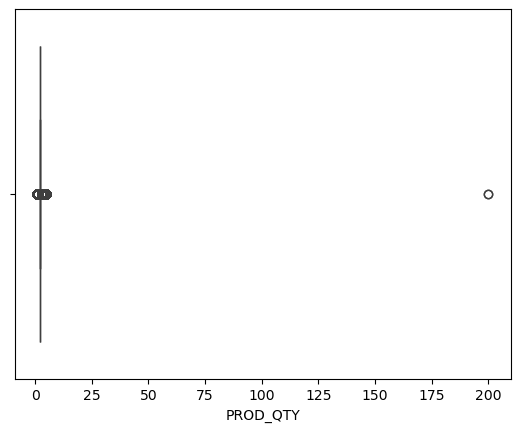

In [47]:
# check outliers
sns.boxplot(x = transactions['PROD_QTY'])

In [48]:
transactions[transactions['PROD_QTY'] > 25]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,SIZE,BRAND_NAME
69762,2018-08-19,226,226000,226201,4,dorito corn chp supreme 380g,200,650.0,380,doritos
69763,2019-05-20,226,226000,226210,4,dorito corn chp supreme 380g,200,650.0,380,doritos


In [49]:
transactions[transactions['LYLTY_CARD_NBR'] == 226000]
# this customer has only made 2 transactions

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,SIZE,BRAND_NAME
69762,2018-08-19,226,226000,226201,4,dorito corn chp supreme 380g,200,650.0,380,doritos
69763,2019-05-20,226,226000,226210,4,dorito corn chp supreme 380g,200,650.0,380,doritos


In [50]:
# eliminate outlier
transactions = transactions[transactions['PROD_QTY'] < 25]

In [51]:
transactions['PROD_QTY'].describe()

count    246740.000000
mean          1.906456
std           0.342499
min           1.000000
25%           2.000000
50%           2.000000
75%           2.000000
max           5.000000
Name: PROD_QTY, dtype: float64

<Axes: xlabel='PROD_QTY'>

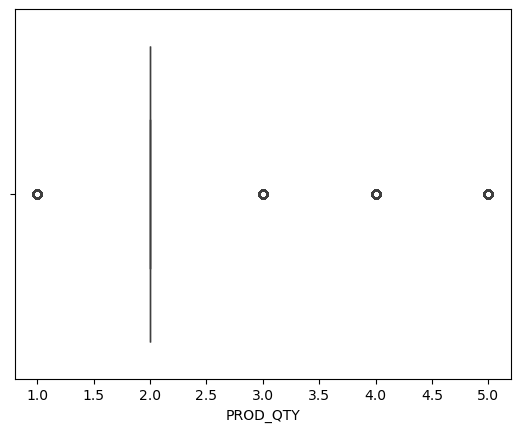

In [52]:
sns.boxplot(x = transactions['PROD_QTY'])

In [53]:
transactions['PROD_QTY'].value_counts()

PROD_QTY
2    220070
1     25476
5       415
3       408
4       371
Name: count, dtype: int64

In [54]:
# total sales
transactions['TOT_SALES'].describe()

count    246740.000000
mean          7.316113
std           2.474897
min           1.700000
25%           5.800000
50%           7.400000
75%           8.800000
max          29.500000
Name: TOT_SALES, dtype: float64

<Axes: xlabel='TOT_SALES'>

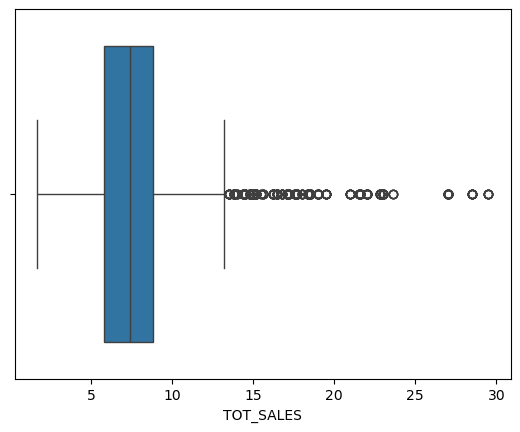

In [55]:
sns.boxplot(x = transactions['TOT_SALES'])

In [56]:
# merge tables
merged_df = transactions.merge(customers, how = 'left', on = 'LYLTY_CARD_NBR')

In [57]:
merged_df.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,SIZE,BRAND_NAME,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,natural chip compny seasalt175g,2,6.0,175,natural,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,ccs nacho cheese 175g,3,6.3,175,ccs,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,smiths crinkle cut chips chicken 170g,2,2.9,170,smiths,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,smiths chip thinly s/cream&onion 175g,5,15.0,175,smiths,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,kettle tortilla chpshny&jlpno chili 150g,3,13.8,150,kettle,MIDAGE SINGLES/COUPLES,Budget


# Customer analysis

In [58]:
# sales percent by lifestage 
sales_ls = merged_df.groupby('LIFESTAGE')['TOT_SALES'].sum().sort_values(ascending=False)
sales_ls = np.round((sales_ls/sales_ls.sum())*100,2)
sales_ls

LIFESTAGE
OLDER SINGLES/COUPLES     20.83
RETIREES                  18.97
OLDER FAMILIES            18.20
YOUNG FAMILIES            16.32
YOUNG SINGLES/COUPLES     13.50
MIDAGE SINGLES/COUPLES     9.56
NEW FAMILIES               2.62
Name: TOT_SALES, dtype: float64

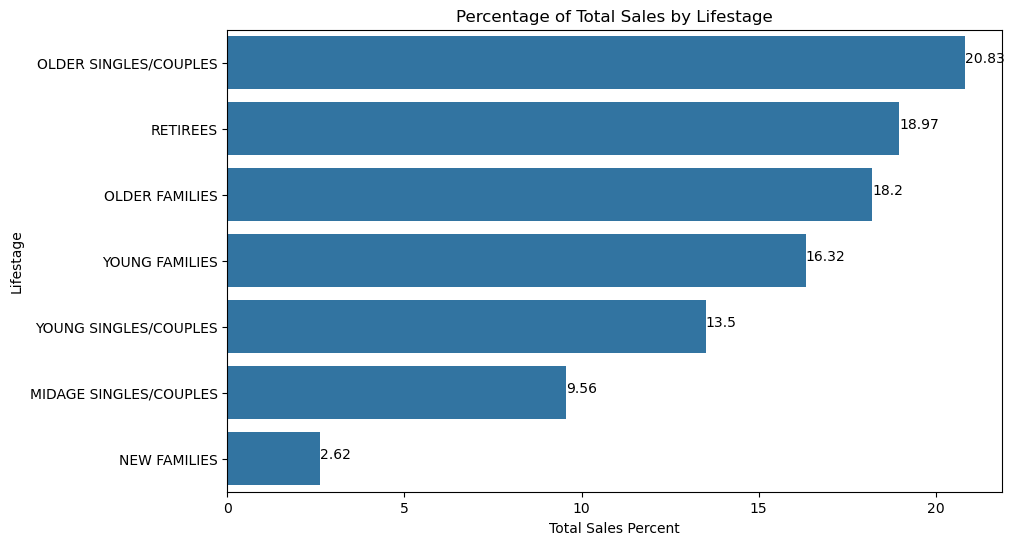

In [59]:
plt.figure(figsize=(10, 6))
sns.barplot(x = sales_ls.values, y = sales_ls.index)

for i, value in enumerate(sales_ls.values):
    plt.text(value, i, value)

plt.xticks(range(0, int(max(sales_ls.values)) + 5, 5))

plt.title("Percentage of Total Sales by Lifestage")
plt.xlabel("Total Sales Percent")
plt.ylabel("Lifestage")

plt.show()

In [60]:
# sales percent by premium customer
sales_pc = merged_df.groupby('PREMIUM_CUSTOMER')['TOT_SALES'].sum().sort_values(ascending=False)
sales_pc = np.round((sales_pc/sales_pc.sum())*100,2)
sales_pc

PREMIUM_CUSTOMER
Mainstream    38.83
Budget        34.98
Premium       26.20
Name: TOT_SALES, dtype: float64

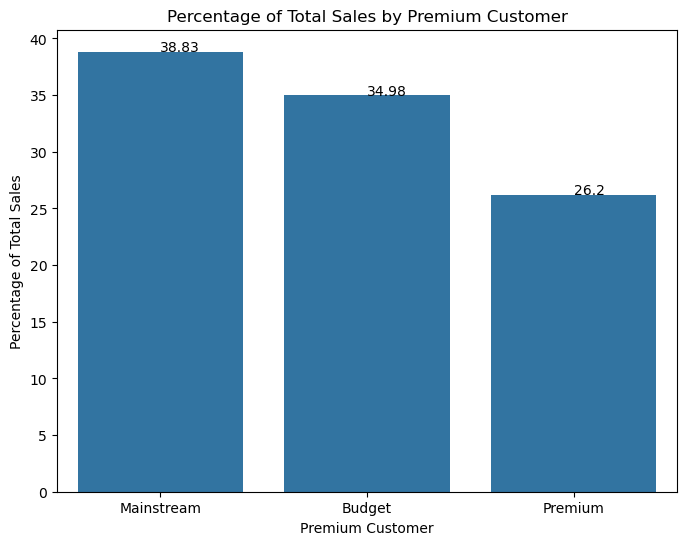

In [61]:
plt.figure(figsize=(8, 6))

sns.barplot(x = sales_pc.index, y = sales_pc.values)

for i, value in enumerate(sales_pc.values):
    plt.text(i, value, value)

plt.yticks(range(0, int(max(sales_pc.values)) + 5, 5))

plt.title("Percentage of Total Sales by Premium Customer")
plt.xlabel("Premium Customer")
plt.ylabel("Percentage of Total Sales")

plt.show()

In [62]:
# sales percent by lifestage & premium customer
sales_lp = merged_df.groupby(['LIFESTAGE','PREMIUM_CUSTOMER'])['TOT_SALES'].sum().reset_index()
sales_lp.TOT_SALES = np.round((sales_lp.TOT_SALES/sales_lp.TOT_SALES.sum())*100,2)
sales_lp.sort_values(by="TOT_SALES", ascending=False)
# budget older families, mainstream yound singles and couples, mainstream retirees

,LIFESTAGE,PREMIUM_CUSTOMER,TOT_SALES
6,OLDER FAMILIES,Budget,8.69
19,YOUNG SINGLES/COUPLES,Mainstream,8.18
13,RETIREES,Mainstream,8.04
15,YOUNG FAMILIES,Budget,7.19
9,OLDER SINGLES/COUPLES,Budget,7.08
10,OLDER SINGLES/COUPLES,Mainstream,6.91
11,OLDER SINGLES/COUPLES,Premium,6.84
12,RETIREES,Budget,5.87
7,OLDER FAMILIES,Mainstream,5.34
14,RETIREES,Premium,5.06


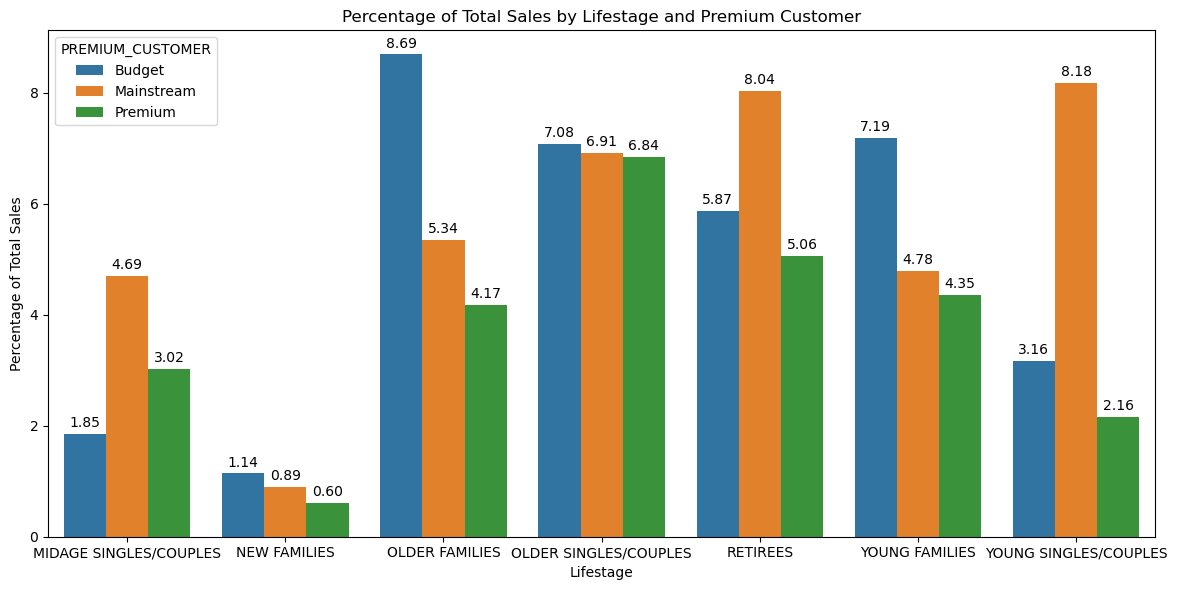

In [105]:
plt.figure(figsize = (12, 6))
graph = sns.barplot(data = sales_lp, y = 'TOT_SALES', x = 'LIFESTAGE', hue = 'PREMIUM_CUSTOMER')
for p in graph.patches:
    if p.get_height() > 0:
        graph.annotate(
            f"{p.get_height():.2f}",
            (p.get_x() + p.get_width()/2, p.get_height()),
            ha="center",
            xytext=(0, 5),
            textcoords="offset points"
        )
    
plt.title('Percentage of Total Sales by Lifestage and Premium Customer')
plt.xlabel('Lifestage')
plt.ylabel('Percentage of Total Sales')
plt.tight_layout()

The top 3 customer segments that contributes to sales:

- budget older families
- mainstream yound singles and couples
- mainstream retirees

reason1: higher sales - more no. of customers who buy chips in these categories ?

In [101]:
top_3_sales = merged_df[
    ((merged_df['LIFESTAGE'] == 'OLDER FAMILIES') & 
     (merged_df['PREMIUM_CUSTOMER'] == 'Budget')) |
    
    ((merged_df['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES') & 
     (merged_df['PREMIUM_CUSTOMER'] == 'Mainstream')) |
    
    ((merged_df['LIFESTAGE'] == 'RETIREES') & 
     (merged_df['PREMIUM_CUSTOMER'] == 'Mainstream'))
]['TOT_SALES'].sum()

total_sales = merged_df['TOT_SALES'].sum()

top_3_sales_percent = (top_3_sales / total_sales) * 100

print(f"Top 3 segments together contribute {top_3_sales_percent:.2f}% of total sales")

Top 3 segments together contribute 24.91% of total sales


In [64]:
# percent of customers in each segment
customer_lp = merged_df.groupby(['LIFESTAGE','PREMIUM_CUSTOMER'])['LYLTY_CARD_NBR'].nunique().reset_index()
customer_lp.LYLTY_CARD_NBR = np.round((customer_lp.LYLTY_CARD_NBR/customer_lp.LYLTY_CARD_NBR.sum())*100,2)
customer_lp.sort_values(by="LYLTY_CARD_NBR", ascending=False)
# mainstream yound singles, couples, mainstream retirees only 

,LIFESTAGE,PREMIUM_CUSTOMER,LYLTY_CARD_NBR
19,YOUNG SINGLES/COUPLES,Mainstream,11.11
13,RETIREES,Mainstream,8.92
10,OLDER SINGLES/COUPLES,Mainstream,6.81
9,OLDER SINGLES/COUPLES,Budget,6.80
11,OLDER SINGLES/COUPLES,Premium,6.57
6,OLDER FAMILIES,Budget,6.47
12,RETIREES,Budget,6.15
15,YOUNG FAMILIES,Budget,5.55
14,RETIREES,Premium,5.35
18,YOUNG SINGLES/COUPLES,Budget,5.12


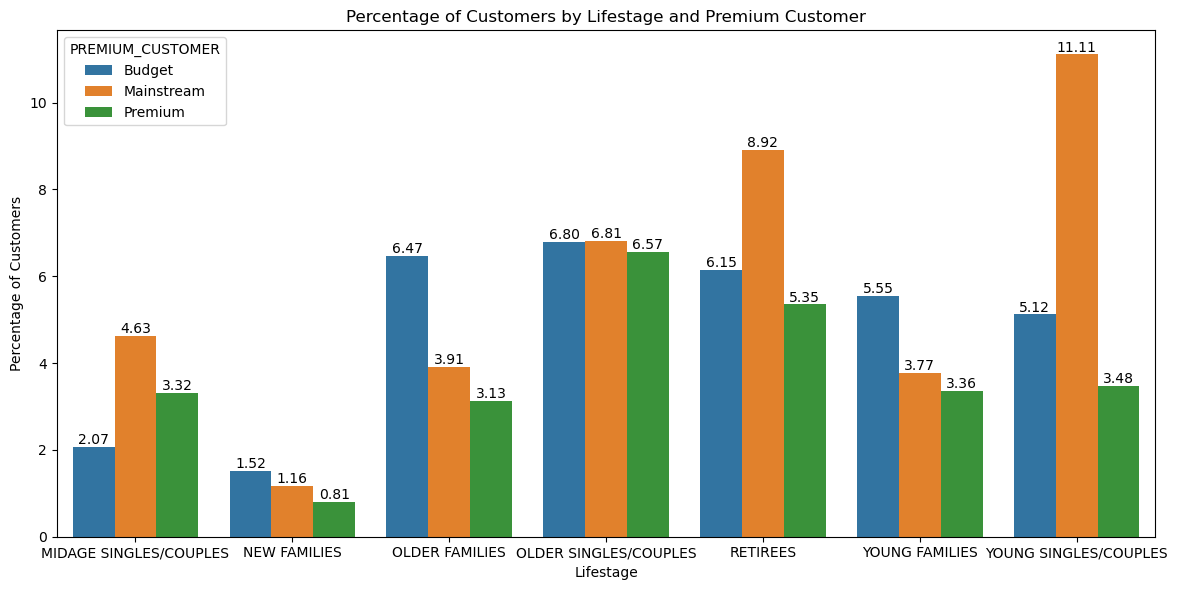

In [65]:
plt.figure(figsize=(12, 6))

graph = sns.barplot(data = customer_lp, y = 'LYLTY_CARD_NBR', x = 'LIFESTAGE', hue = 'PREMIUM_CUSTOMER')
for p in graph.patches:
    if p.get_height() > 0:
        graph.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')
    
plt.title('Percentage of Customers by Lifestage and Premium Customer')
plt.xlabel('Lifestage')
plt.ylabel('Percentage of Customers')

plt.tight_layout()

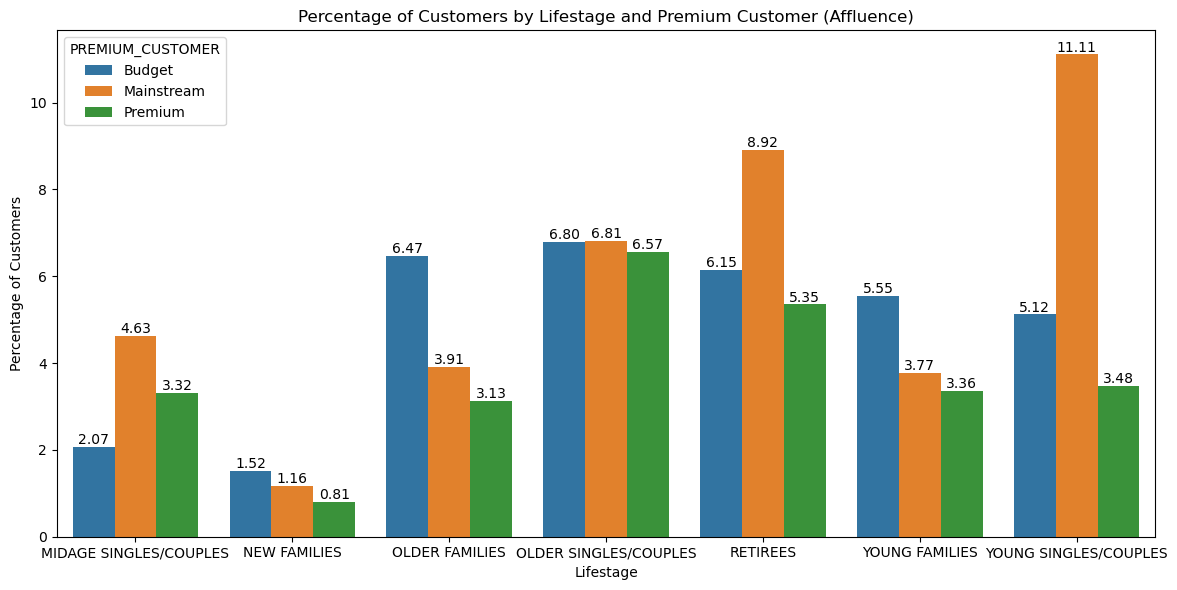

In [106]:
plt.figure(figsize=(12, 6))

graph = sns.barplot(data = customer_lp, y = 'LYLTY_CARD_NBR', x = 'LIFESTAGE', hue = 'PREMIUM_CUSTOMER')
for p in graph.patches:
    if p.get_height() > 0:
        graph.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')
    
plt.title('Percentage of Customers by Lifestage and Premium Customer (Affluence)')
plt.xlabel('Lifestage')
plt.ylabel('Percentage of Customers')

plt.tight_layout()

no. of customers is the driver for sales in:

- mainstream yound singles and couples
- mainstream retirees

But not in budget older families

reason2: higher sales - more purchases per customer (more units bought per customer in a segment) ?

In [66]:
# avg units bought per customer in a segment
# Units per Customer = Total Units Purchased / No. of Unique Customers
avg_units = merged_df.groupby(['LIFESTAGE','PREMIUM_CUSTOMER']).agg({'PROD_QTY': ['sum'], 'LYLTY_CARD_NBR':['nunique']})
avg_units['units_per_customer'] = avg_units[('PROD_QTY', 'sum')] / avg_units[('LYLTY_CARD_NBR', 'nunique')]
avg_units = avg_units.reset_index()
avg_units.sort_values(by="units_per_customer", ascending=False)

,LIFESTAGE,PREMIUM_CUSTOMER,PROD_QTY,LYLTY_CARD_NBR,units_per_customer
,,,sum,nunique,
7,OLDER FAMILIES,Mainstream,25804,2788,9.255380
6,OLDER FAMILIES,Budget,41853,4611,9.076773
8,OLDER FAMILIES,Premium,20239,2231,9.071717
15,YOUNG FAMILIES,Budget,34482,3953,8.722995
17,YOUNG FAMILIES,Premium,20901,2398,8.716013
16,YOUNG FAMILIES,Mainstream,23194,2685,8.638361
9,OLDER SINGLES/COUPLES,Budget,32883,4849,6.781398
11,OLDER SINGLES/COUPLES,Premium,31695,4682,6.769543
10,OLDER SINGLES/COUPLES,Mainstream,32607,4858,6.712021


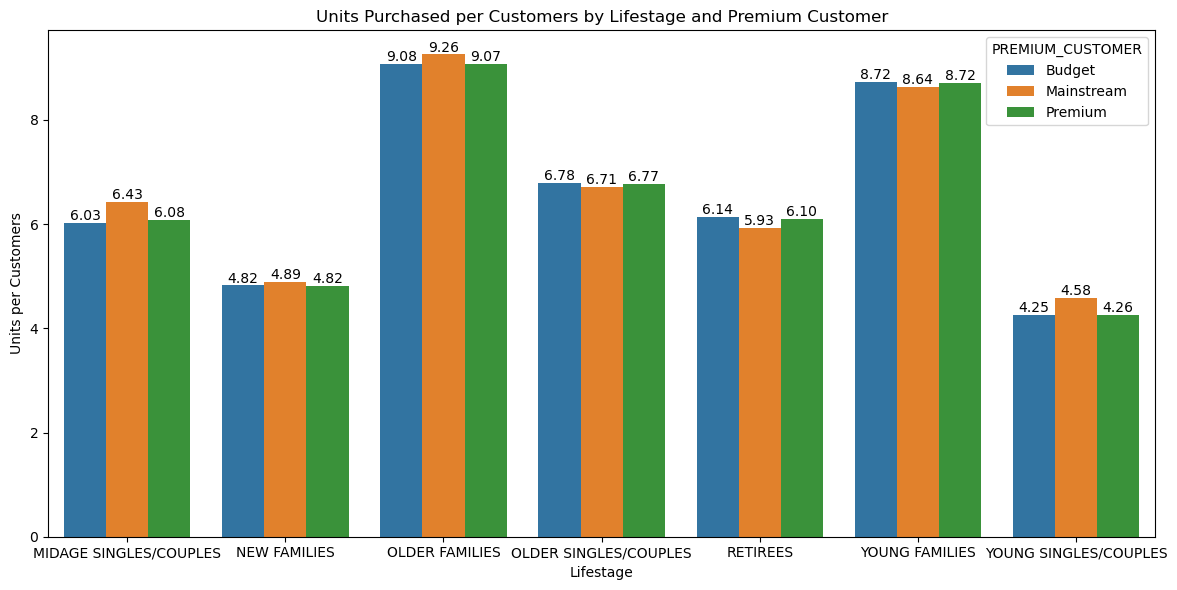

In [97]:
plt.figure(figsize=(12, 6))

graph = sns.barplot(data = avg_units, y = 'units_per_customer', x = 'LIFESTAGE', hue='PREMIUM_CUSTOMER')
for p in graph.patches:
    if p.get_height() > 0:
        graph.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')
    
plt.title('Units Purchased per Customers by Lifestage and Premium Customer')
plt.xlabel('Lifestage')
plt.ylabel('Units per Customers')

plt.tight_layout()

- older and younger families bought most chips per customer
- why ?

reason3: price level of the products customers are buying is the driver of total sales ?

- average price per unit chips bought for each customer segment

In [68]:
# Average Price per Unit = Total Sales / Total Units Purchased 
avg_price = merged_df.groupby(['LIFESTAGE','PREMIUM_CUSTOMER']).agg({'TOT_SALES':['sum'], 'PROD_QTY':['sum']})
avg_price['average_price_per_unit_purchased'] = avg_price[('TOT_SALES', 'sum')] / avg_price[('PROD_QTY', 'sum')]
avg_price = avg_price.reset_index()
avg_price.sort_values(by="average_price_per_unit_purchased", ascending=False)

,LIFESTAGE,PREMIUM_CUSTOMER,TOT_SALES,PROD_QTY,average_price_per_unit_purchased
,,,sum,sum,
19,YOUNG SINGLES/COUPLES,Mainstream,147582.20,36225,4.074043
1,MIDAGE SINGLES/COUPLES,Mainstream,84734.25,21213,3.994449
4,NEW FAMILIES,Mainstream,15979.70,4060,3.935887
12,RETIREES,Budget,105916.30,26932,3.932731
3,NEW FAMILIES,Budget,20607.45,5241,3.931969
14,RETIREES,Premium,91296.65,23266,3.924037
11,OLDER SINGLES/COUPLES,Premium,123537.55,31695,3.897698
9,OLDER SINGLES/COUPLES,Budget,127833.60,32883,3.887529
5,NEW FAMILIES,Premium,10760.80,2769,3.886168


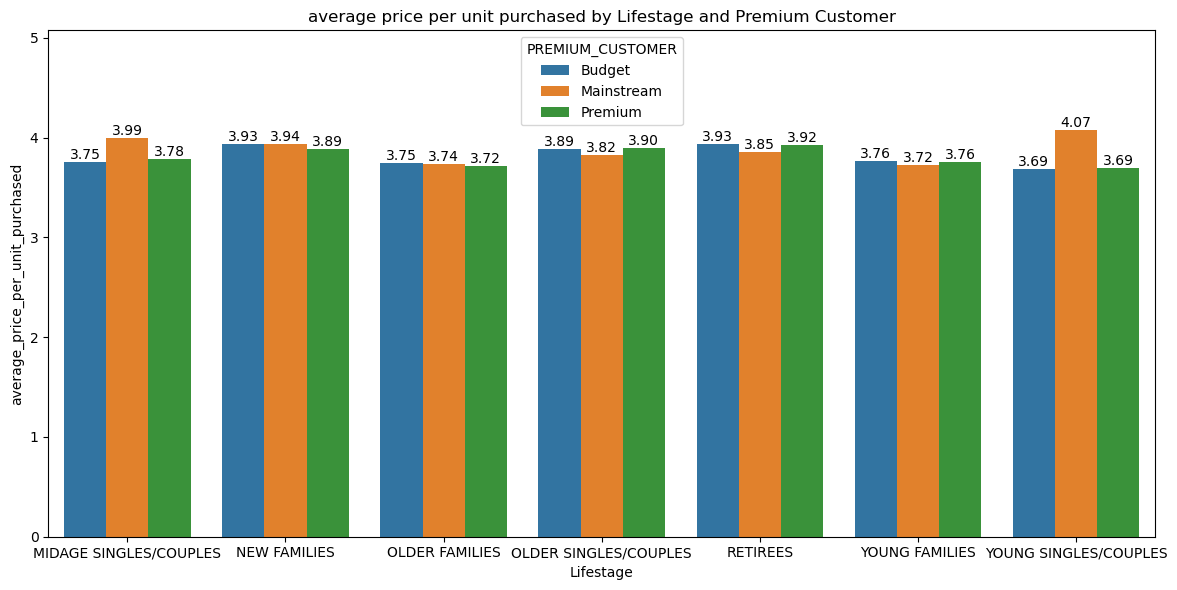

In [69]:
plt.figure(figsize=(12, 6))

graph = sns.barplot(data = avg_price, y='average_price_per_unit_purchased', x='LIFESTAGE', hue='PREMIUM_CUSTOMER')

for p in graph.patches:
    if p.get_height() > 0:
        graph.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')
        
plt.title('average price per unit purchased by Lifestage and Premium Customer')
plt.xlabel('Lifestage')
plt.ylabel('average_price_per_unit_purchased')
plt.ylim(0, avg_price["average_price_per_unit_purchased"].max() + 1)

plt.tight_layout()

1. midage singles/couples and young singles/couples have the most difference in average price per unit purchased across 3 categories
  - midstream spending more for single packet of chips in these categories
2. budget customers in these categories might be aiming to save on purchases
  - budget older families bought more units but spent less on single packet of chips

## Product analysis 



By: 
1. preferred customers (top 3 segments by total sales)
- budget older families
- mainstream yound singles and couples
- mainstream retirees
  
2. other customers 

In [70]:
merged_df.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,SIZE,BRAND_NAME,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,natural chip compny seasalt175g,2,6.0,175,natural,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,ccs nacho cheese 175g,3,6.3,175,ccs,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,smiths crinkle cut chips chicken 170g,2,2.9,170,smiths,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,smiths chip thinly s/cream&onion 175g,5,15.0,175,smiths,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,kettle tortilla chpshny&jlpno chili 150g,3,13.8,150,kettle,MIDAGE SINGLES/COUPLES,Budget


In [71]:
preferred = merged_df[((merged_df['LIFESTAGE'] == 'OLDER FAMILIES' ) & (merged_df['PREMIUM_CUSTOMER'] == 'Budget' )) | ((merged_df['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES' ) & (merged_df['PREMIUM_CUSTOMER'] == 'Mainstream' )) | ((merged_df['LIFESTAGE'] == 'RETIREES' ) & (merged_df['PREMIUM_CUSTOMER'] == 'Mainstream' ))]
preferred

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,SIZE,BRAND_NAME,LIFESTAGE,PREMIUM_CUSTOMER
29896,2018-07-21,77,2330461,236777,87,infuzions bbq rib prawn crackers 110g,1,3.8,110,infuzions,OLDER FAMILIES,Budget
29897,2019-05-20,1,1367,424,7,smiths crinkle original 330g,1,5.7,330,smiths,OLDER FAMILIES,Budget
29898,2018-08-17,3,3088,1462,89,kettle sweet chilli and sour cream 175g,2,10.8,175,kettle,OLDER FAMILIES,Budget
29899,2018-08-14,3,3147,1698,16,smiths crinkle chips salt & vinegar 330g,1,5.7,330,smiths,OLDER FAMILIES,Budget
29900,2019-05-16,3,3206,1979,71,twisties cheese burger 250g,1,4.3,250,twisties,OLDER FAMILIES,Budget
...,...,...,...,...,...,...,...,...,...,...,...,...
240884,2018-12-01,272,272377,270186,75,cobs popd sea salt chips 110g,2,7.6,110,cobs,YOUNG SINGLES/COUPLES,Mainstream
240885,2018-07-27,272,272389,270200,114,kettle sensations siracha lime 150g,2,9.2,150,kettle,YOUNG SINGLES/COUPLES,Mainstream
240886,2018-11-10,272,272389,270201,26,pringles sweet&spcy bbq 134g,2,7.4,134,pringles,YOUNG SINGLES/COUPLES,Mainstream
240887,2019-04-01,272,272389,270202,62,pringles mystery flavour 134g,2,7.4,134,pringles,YOUNG SINGLES/COUPLES,Mainstream


In [72]:
other = merged_df[~(((merged_df['LIFESTAGE'] == 'OLDER FAMILIES' ) & (merged_df['PREMIUM_CUSTOMER'] == 'Budget' )) | ((merged_df['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES' ) & (merged_df['PREMIUM_CUSTOMER'] == 'Mainstream' )) | ((merged_df['LIFESTAGE'] == 'RETIREES' ) & (merged_df['PREMIUM_CUSTOMER'] == 'Mainstream' )))]
other

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,SIZE,BRAND_NAME,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,natural chip compny seasalt175g,2,6.0,175,natural,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,ccs nacho cheese 175g,3,6.3,175,ccs,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,smiths crinkle cut chips chicken 170g,2,2.9,170,smiths,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,smiths chip thinly s/cream&onion 175g,5,15.0,175,smiths,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,kettle tortilla chpshny&jlpno chili 150g,3,13.8,150,kettle,MIDAGE SINGLES/COUPLES,Budget
...,...,...,...,...,...,...,...,...,...,...,...,...
246735,2019-03-09,272,272319,270088,89,kettle sweet chilli and sour cream 175g,2,10.8,175,kettle,YOUNG SINGLES/COUPLES,Premium
246736,2018-08-13,272,272358,270154,74,tostitos splash of lime 175g,1,4.4,175,tostitos,YOUNG SINGLES/COUPLES,Premium
246737,2018-11-06,272,272379,270187,51,doritos mexicana 170g,2,8.8,170,doritos,YOUNG SINGLES/COUPLES,Premium
246738,2018-12-27,272,272379,270188,42,doritos corn chip mexican jalapeno 150g,2,7.8,150,doritos,YOUNG SINGLES/COUPLES,Premium


In [73]:
# out of all products purchased by the preferred customer segment, percent that came from each brand
preferred_brand = preferred.groupby(['BRAND_NAME'])['PROD_QTY'].sum()
preferred_brand = (preferred_brand/preferred_brand.sum())*100
preferred_brand = preferred_brand.reset_index()
preferred_brand.rename(columns = {'PROD_QTY':'Purchase_Proportion_Preferred'}, inplace=True)

In [74]:
preferred_brand.sort_values(by = "Purchase_Proportion_Preferred", ascending=False)

,BRAND_NAME,Purchase_Proportion_Preferred
9,kettle,17.357350
13,smiths,11.774869
5,doritos,10.689819
11,pringles,10.527407
12,red,6.187206
8,infuzions,5.953954
15,thins,5.826098
19,woolworths,4.224440
17,twisties,4.131139
4,cobs,3.968727


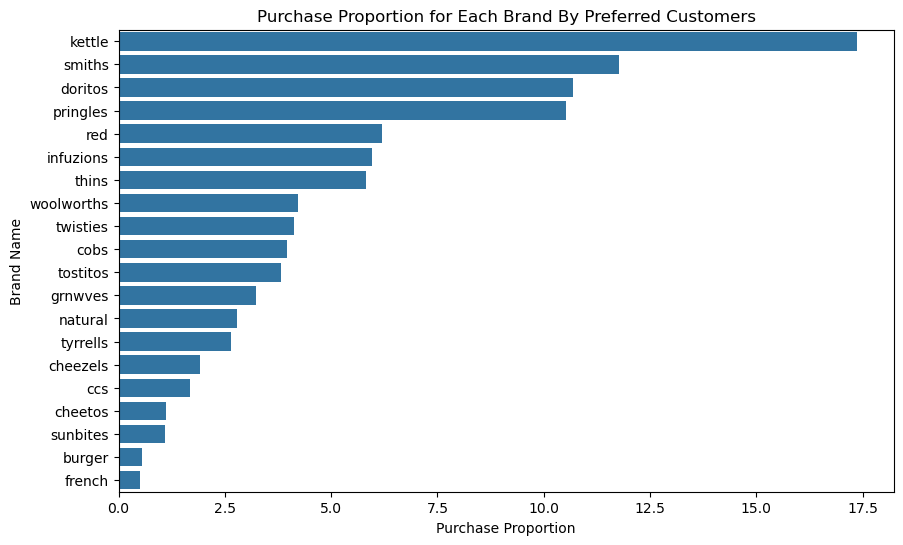

In [75]:
# brands preferred by our 'preferred' customers
preferred_brand = preferred_brand.sort_values(by='Purchase_Proportion_Preferred', ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(data=preferred_brand, x='Purchase_Proportion_Preferred', y='BRAND_NAME')

plt.xlabel('Purchase Proportion')
plt.ylabel('Brand Name')
plt.title('Purchase Proportion for Each Brand By Preferred Customers')

plt.show()

The most preferred brands by preferred segment:
- kettle
- smith
- doritos
- pringles
- red

In [76]:
other_brand = other.groupby(['BRAND_NAME'])['PROD_QTY'].sum()
other_brand = (other_brand / other_brand.sum()) * 100
other_brand = other_brand.reset_index()
other_brand.rename(columns = {'PROD_QTY':'Purchase_Proportion_Other'}, inplace=True)

In [77]:
other_brand.sort_values(by = "Purchase_Proportion_Other", ascending=False)

,BRAND_NAME,Purchase_Proportion_Other
9,kettle,16.624841
13,smiths,12.393273
5,doritos,10.138900
11,pringles,10.103935
12,red,6.690935
8,infuzions,5.703466
15,thins,5.691623
19,woolworths,4.918453
4,cobs,3.941135
16,tostitos,3.866413


In [78]:
preffered_brand_affinity = pd.merge(preferred_brand, other_brand, on='BRAND_NAME')
preffered_brand_affinity

,BRAND_NAME,Purchase_Proportion_Preferred,Purchase_Proportion_Other
0,kettle,17.357350,16.624841
1,smiths,11.774869,12.393273
2,doritos,10.689819,10.138900
3,pringles,10.527407,10.103935
4,red,6.187206,6.690935
5,infuzions,5.953954,5.703466
6,thins,5.826098,5.691623
7,woolworths,4.224440,4.918453
8,twisties,4.131139,3.760391
9,cobs,3.968727,3.941135


In [79]:
# Affinity = Purchase proportion of preferred segment / Purchase proportion of other customers
preffered_brand_affinity['affinity'] = (preffered_brand_affinity['Purchase_Proportion_Preferred'] / preffered_brand_affinity['Purchase_Proportion_Other'])
preffered_brand_affinity

,BRAND_NAME,Purchase_Proportion_Preferred,Purchase_Proportion_Other,affinity
0,kettle,17.357350,16.624841,1.044061
1,smiths,11.774869,12.393273,0.950102
2,doritos,10.689819,10.138900,1.054337
3,pringles,10.527407,10.103935,1.041912
4,red,6.187206,6.690935,0.924715
5,infuzions,5.953954,5.703466,1.043919
6,thins,5.826098,5.691623,1.023627
7,woolworths,4.224440,4.918453,0.858896
8,twisties,4.131139,3.760391,1.098593
9,cobs,3.968727,3.941135,1.007001


In [80]:
preffered_brand_affinity = round(preffered_brand_affinity,3)
preffered_brand_affinity

,BRAND_NAME,Purchase_Proportion_Preferred,Purchase_Proportion_Other,affinity
0,kettle,17.357,16.625,1.044
1,smiths,11.775,12.393,0.950
2,doritos,10.690,10.139,1.054
3,pringles,10.527,10.104,1.042
4,red,6.187,6.691,0.925
5,infuzions,5.954,5.703,1.044
6,thins,5.826,5.692,1.024
7,woolworths,4.224,4.918,0.859
8,twisties,4.131,3.760,1.099
9,cobs,3.969,3.941,1.007


In [81]:
preffered_brand_affinity.describe()

,Purchase_Proportion_Preferred,Purchase_Proportion_Other,affinity
count,20.000000,20.000000,20.000000
mean,5.000000,4.999850,0.973850
std,4.428807,4.290985,0.077405
min,0.515000,0.577000,0.833000
25%,1.856000,1.868250,0.907500
50%,3.894500,3.813000,0.997500
75%,6.012250,5.950000,1.042250
max,17.357000,16.625000,1.099000


- The preferred customers buys brands in almost the same proportions as everyone else. They don't show a particularly strong preference for any one brand as compared to other customers.

In [82]:
# pakage sizes

In [83]:
# preferred = merged_data[((merged_data['LIFESTAGE'] == 'OLDER FAMILIES' ) & (merged_data['PREMIUM_CUSTOMER'] == 'Budget' )) | ((merged_data['LIFESTAGE'] == 'RETIREES' ) & (merged_data['PREMIUM_CUSTOMER'] == 'Mainstream' )) | ((merged_data['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES' ) & (merged_data['PREMIUM_CUSTOMER'] == 'Mainstream' ))]
# other = merged_data[~(((merged_data['LIFESTAGE'] == 'OLDER FAMILIES' ) & (merged_data['PREMIUM_CUSTOMER'] == 'Budget' )) | ((merged_data['LIFESTAGE'] == 'RETIREES' ) & (merged_data['PREMIUM_CUSTOMER'] == 'Mainstream' )) | ((merged_data['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES' ) & (merged_data['PREMIUM_CUSTOMER'] == 'Mainstream' )))]

In [84]:
preferred_size = preferred.groupby(['SIZE'])['PROD_QTY'].sum()
preferred_size = (preferred_size/preferred_size.sum())*100
preferred_size = preferred_size.reset_index()
preferred_size.rename(columns = {'PROD_QTY':'Purchase_Proportion_Preferred'}, inplace=True)
preferred_size.sort_values(by = "Purchase_Proportion_Preferred", ascending=False)

,SIZE,Purchase_Proportion_Preferred
8,175,26.371215
4,150,16.309447
2,134,10.527407
0,110,9.374109
7,170,8.197486
6,165,5.933221
16,330,5.420068
15,270,2.738543
17,380,2.678070
12,210,2.642650


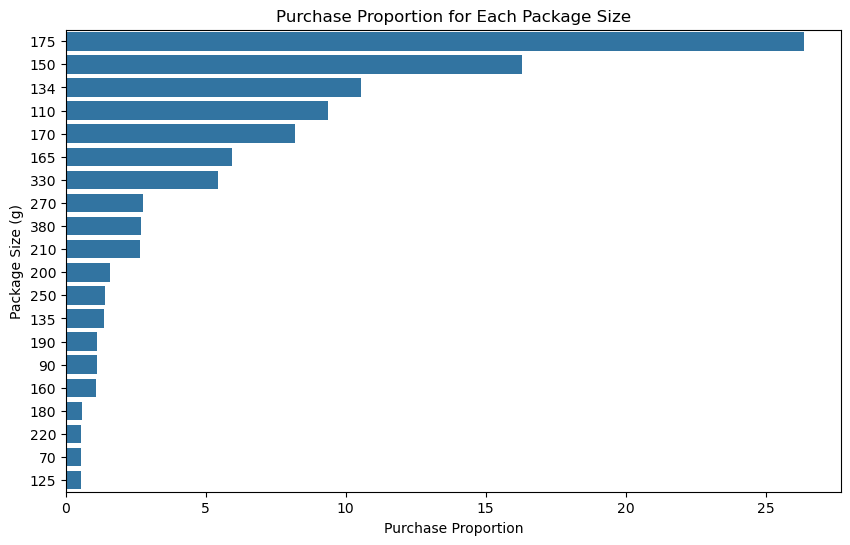

In [85]:
# sizes preferred by our 'preferred' customers
preferred_size = preferred_size.sort_values(by = 'Purchase_Proportion_Preferred', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x = 'Purchase_Proportion_Preferred', y = 'SIZE', data = preferred_size)

plt.xlabel('Purchase Proportion')
plt.ylabel('Package Size (g)')
plt.title('Purchase Proportion for Each Package Size')

plt.show()

The most preferred sizes by preferred segment: 
- 175g
- 150g
- 134g
- 110g
- 170g

In [86]:
other_size = other.groupby(['SIZE'])['PROD_QTY'].sum()
other_size = (other_size / other_size.sum()) * 100
other_size = other_size.reset_index()
other_size.rename(columns = {'PROD_QTY':'Purchase_Proportion_Other'}, inplace=True)
other_size.sort_values(by = "Purchase_Proportion_Other", ascending=False)

,SIZE,Purchase_Proportion_Other
8,175,27.052763
4,150,16.293241
2,134,10.103935
0,110,9.018621
7,170,8.064143
6,165,6.255005
16,330,4.997970
17,380,2.586537
12,210,2.510405
15,270,2.503637


In [87]:
# Affinity
preferred_size_affinity = pd.merge(preferred_size, other_size, on='SIZE')
preferred_size_affinity

,SIZE,Purchase_Proportion_Preferred,Purchase_Proportion_Other
0,175,26.371215,27.052763
1,150,16.309447,16.293241
2,134,10.527407,10.103935
3,110,9.374109,9.018621
4,170,8.197486,8.064143
5,165,5.933221,6.255005
6,330,5.420068,4.997970
7,270,2.738543,2.503637
8,380,2.678070,2.586537
9,210,2.642650,2.510405


In [88]:
preferred_size_affinity['affinity'] = preferred_size_affinity['Purchase_Proportion_Preferred'] / preferred_size_affinity['Purchase_Proportion_Other']
preferred_size_affinity = round(preferred_size_affinity,3)
preferred_size_affinity

,SIZE,Purchase_Proportion_Preferred,Purchase_Proportion_Other,affinity
0,175,26.371,27.053,0.975
1,150,16.309,16.293,1.001
2,134,10.527,10.104,1.042
3,110,9.374,9.019,1.039
4,170,8.197,8.064,1.017
5,165,5.933,6.255,0.949
6,330,5.420,4.998,1.084
7,270,2.739,2.504,1.094
8,380,2.678,2.587,1.035
9,210,2.643,2.510,1.053


In [89]:
preferred_size_affinity.describe()

,Purchase_Proportion_Preferred,Purchase_Proportion_Other,affinity
count,20.000000,20.000000,20.00000
mean,5.000000,5.000000,0.97690
std,6.587664,6.657245,0.08795
min,0.547000,0.588000,0.83300
25%,1.093000,1.237250,0.88950
50%,2.103000,2.185000,1.00050
75%,6.499000,6.707250,1.03975
max,26.371000,27.053000,1.10800


- The preferred customers buys size in almost the same proportions as everyone else. They don't show a particularly strong preference for any one size as compared to other customers.

In [90]:
# Insights & Recommendations

- Top sales segments are Budget Older Families, Mainstream Young Singles/Couples, and Mainstream Retirees
- Prioritize these segments in promotional campaigns and category planning as they contribute the highest sales

1. Sales for Mainstream Young Singles/Couples and Mainstream Retirees are driven by a large customer base
- Focus on customer retention and acquisition campaigns to maintain and grow these high-volume segments
  
2. Budget Older Families generate high sales despite having fewer customers because they buy more units per customer
- Promote value packs and multi-buy offers to encourage even larger basket sizes

3. Older and Younger Families purchase the more number of chip units per customer
- Increase availability of family-size packs and bundle offers targeted at family households

4. Mainstream Midage Singles/Couples and Young Singles/Couples pay a higher average price per unit
- Promote premium chip brands and new product launches to these segments, as they are less price-sensitive

5. Budget customers pay less per packet, indicating strong price sensitivity
- Maintain competitive pricing and highlight value-focused promotions to retain these customers

6. Preferred brands are Kettle, Smith's, Doritos, Pringles, and Red Rock Deli
- Ensure these brands remain well stocked and featured, as they account for the majority of purchases

7. Preferred customers purchase brands in similar proportions to all other customers
- Avoid segment-specific brand promotions; broad brand campaigns are likely to be equally effective

8. Most purchased pack sizes are 175g, 150g, 134g, 110g, and 170g
- Prioritize inventory and shelf space for these pack sizes to minimize stock-outs

9. Preferred customers do not show a stronger preference for specific pack sizes than other customers
- Maintain a balanced assortment of popular pack sizes rather than tailoring pack sizes to specific customer segments

In [135]:

# ============================================================
# 1. SELECT MAINSTREAM YOUNG SINGLES/COUPLES
# ============================================================

target_segment = "Mainstream YOUNG SINGLES/COUPLES"

young_mainstream = merged_df[
    merged_df['SEGMENT'] == target_segment
].copy()

# Check that we actually got data
print("Target segment:", target_segment)
print("Number of rows:", len(young_mainstream))
print()


# ============================================================
# 2. CREATE "EVERYONE ELSE" COMPARISON GROUP
# ============================================================

other_customers = merged_df[
    merged_df['SEGMENT'] != target_segment
].copy()

print("Other customers rows:", len(other_customers))
print()


# ============================================================
# 3. BRAND ANALYSIS
# ============================================================

# ---- Target segment: brand purchase proportion ----

segment_brand = (
    young_mainstream
    .groupby('BRAND_NAME')['PROD_QTY']
    .sum()
    .reset_index()
)

segment_brand['Purchase_Proportion_Segment'] = (
    segment_brand['PROD_QTY']
    / segment_brand['PROD_QTY'].sum()
)

segment_brand = segment_brand[
    ['BRAND_NAME', 'Purchase_Proportion_Segment']
]


# ---- Everyone else: brand purchase proportion ----

other_brand = (
    other_customers
    .groupby('BRAND_NAME')['PROD_QTY']
    .sum()
    .reset_index()
)

other_brand['Purchase_Proportion_Other'] = (
    other_brand['PROD_QTY']
    / other_brand['PROD_QTY'].sum()
)

other_brand = other_brand[
    ['BRAND_NAME', 'Purchase_Proportion_Other']
]


# ---- Combine both ----

brand_analysis = pd.merge(
    segment_brand,
    other_brand,
    on='BRAND_NAME',
    how='inner'
)


# ---- Calculate affinity ----

brand_analysis['Affinity'] = (
    brand_analysis['Purchase_Proportion_Segment']
    / brand_analysis['Purchase_Proportion_Other']
)


# ---- Convert proportions to percentages ----

brand_analysis['Segment_%'] = (
    brand_analysis['Purchase_Proportion_Segment'] * 100
)

brand_analysis['Other_%'] = (
    brand_analysis['Purchase_Proportion_Other'] * 100
)


# ---- Calculate "more likely %" ----

brand_analysis['More_Likely_%'] = (
    (brand_analysis['Affinity'] - 1) * 100
)


# ---- Sort by affinity ----

brand_analysis = brand_analysis.sort_values(
    'Affinity',
    ascending=False
).reset_index(drop=True)


# ============================================================
# 4. DISPLAY BRAND RESULTS
# ============================================================

print("=" * 70)
print("BRAND AFFINITY — MAINSTREAM YOUNG SINGLES/COUPLES")
print("=" * 70)

print(
    brand_analysis[
        [
            'BRAND_NAME',
            'Segment_%',
            'Other_%',
            'Affinity',
            'More_Likely_%'
        ]
    ].round(2).to_string(index=False)
)


# ============================================================
# 5. HIGHEST AFFINITY BRAND
# ============================================================

top_brand = brand_analysis.iloc[0]

print("\n" + "=" * 70)
print("HIGHEST AFFINITY BRAND")
print("=" * 70)

print(
    f"{top_brand['BRAND_NAME']} "
    f"has an affinity of {top_brand['Affinity']:.2f}"
)

print(
    f"This segment is {top_brand['More_Likely_%']:.0f}% "
    f"more likely to purchase {top_brand['BRAND_NAME']}."
)


# ============================================================
# 6. PACKET SIZE ANALYSIS
# ============================================================

# Make sure SIZE is numeric
young_mainstream['SIZE'] = pd.to_numeric(
    young_mainstream['SIZE'],
    errors='coerce'
)

other_customers['SIZE'] = pd.to_numeric(
    other_customers['SIZE'],
    errors='coerce'
)

# Remove missing sizes
young_size_data = young_mainstream.dropna(subset=['SIZE'])
other_size_data = other_customers.dropna(subset=['SIZE'])


# ---- Target segment: size purchase proportion ----

segment_size = (
    young_size_data
    .groupby('SIZE')['PROD_QTY']
    .sum()
    .reset_index()
)

segment_size['Purchase_Proportion_Segment'] = (
    segment_size['PROD_QTY']
    / segment_size['PROD_QTY'].sum()
)

segment_size = segment_size[
    ['SIZE', 'Purchase_Proportion_Segment']
]


# ---- Everyone else: size purchase proportion ----

other_size = (
    other_size_data
    .groupby('SIZE')['PROD_QTY']
    .sum()
    .reset_index()
)

other_size['Purchase_Proportion_Other'] = (
    other_size['PROD_QTY']
    / other_size['PROD_QTY'].sum()
)

other_size = other_size[
    ['SIZE', 'Purchase_Proportion_Other']
]


# ---- Combine ----

size_analysis = pd.merge(
    segment_size,
    other_size,
    on='SIZE',
    how='inner'
)


# ---- Affinity ----

size_analysis['Affinity'] = (
    size_analysis['Purchase_Proportion_Segment']
    / size_analysis['Purchase_Proportion_Other']
)


# ---- Percentages ----

size_analysis['Segment_%'] = (
    size_analysis['Purchase_Proportion_Segment'] * 100
)

size_analysis['Other_%'] = (
    size_analysis['Purchase_Proportion_Other'] * 100
)


# ---- More likely % ----

size_analysis['More_Likely_%'] = (
    (size_analysis['Affinity'] - 1) * 100
)


# ---- Sort ----

size_analysis = size_analysis.sort_values(
    'Affinity',
    ascending=False
).reset_index(drop=True)


# ============================================================
# 7. DISPLAY SIZE RESULTS
# ============================================================

print("\n" + "=" * 70)
print("PACKET SIZE AFFINITY — MAINSTREAM YOUNG SINGLES/COUPLES")
print("=" * 70)

print(
    size_analysis[
        [
            'SIZE',
            'Segment_%',
            'Other_%',
            'Affinity',
            'More_Likely_%'
        ]
    ].round(2).to_string(index=False)
)


# ============================================================
# 8. HIGHEST AFFINITY SIZE
# ============================================================

top_size = size_analysis.iloc[0]

print("\n" + "=" * 70)
print("HIGHEST AFFINITY PACKET SIZE")
print("=" * 70)

print(
    f"{int(top_size['SIZE'])}g "
    f"has an affinity of {top_size['Affinity']:.2f}"
)

print(
    f"This segment is {top_size['More_Likely_%']:.0f}% "
    f"more likely to purchase {int(top_size['SIZE'])}g packets."
)



Target segment: Mainstream YOUNG SINGLES/COUPLES
Number of rows: 19544

Other customers rows: 227196

BRAND AFFINITY — MAINSTREAM YOUNG SINGLES/COUPLES
BRAND_NAME  Segment_%  Other_%  Affinity  More_Likely_%
  tyrrells       3.16     2.57      1.23          22.81
  twisties       4.62     3.79      1.22          21.93
   doritos      12.28    10.11      1.21          21.46
    kettle      19.80    16.56      1.20          19.59
  tostitos       4.54     3.80      1.20          19.57
  pringles      11.94    10.06      1.19          18.67
      cobs       4.46     3.90      1.14          14.31
 infuzions       6.47     5.71      1.13          13.34
     thins       6.04     5.70      1.06           5.94
   grnwves       3.27     3.12      1.05           4.89
  cheezels       1.80     1.86      0.96          -3.62
    smiths       9.64    12.46      0.77         -22.65
    french       0.39     0.58      0.69         -31.44
   cheetos       0.80     1.21      0.67         -33.43
       r

In [143]:
merged_df[
    merged_df['SIZE'].isin(['175', '270'])
][
    ['BRAND_NAME', 'SIZE']
].drop_duplicates().sort_values('SIZE')

,BRAND_NAME,SIZE
0,natural,175
1,ccs,175
3,smiths,175
12,woolworths,175
13,thins,175
22,kettle,175
79,french,175
122,tostitos,175
11,twisties,270


In [144]:
merged_df[merged_df['SIZE'] == '270'][
    ['PROD_NBR', 'PROD_NAME', 'BRAND_NAME', 'SIZE']
].drop_duplicates()

,PROD_NBR,PROD_NAME,BRAND_NAME,SIZE
11,15,twisties cheese 270g,twisties,270
39,113,twisties chicken270g,twisties,270
